<a href="https://colab.research.google.com/github/sweetsuyambu6-art/M-L-Prediction-Food-Classification-/blob/main/project_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

accuracy_score:0.9888417763891988
precision_score:0.9888636839416258
f1_score:0.9888437008536848
recall_score:0.9888417763891988

Model: XGBClassifier
accuracy_score:0.9766069546891465
precision_score:0.9767190411748511
f1_score:0.9766168306383113
recall_score:0.9766069546891465


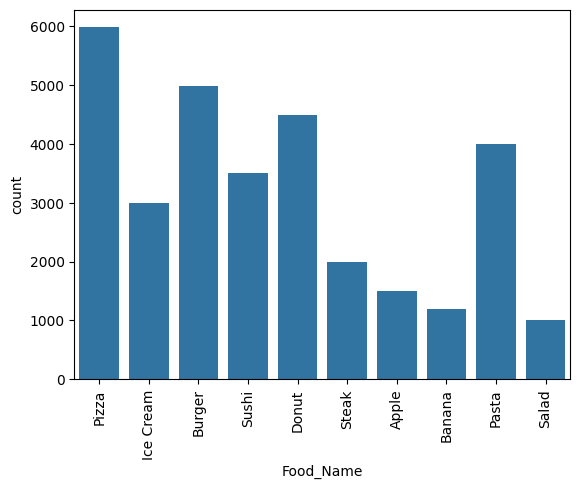

      Actual  Predicted
0     Banana     Banana
1     Burger     Burger
2  Ice Cream  Ice Cream
3      Pasta      Pasta
4      Donut      Donut


In [2]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,f1_score,recall_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

df=pd.read_csv(r"/synthetic_food_dataset_imbalanced.csv")

cols='Calories','Protein','Fat','Carbs','Sugar',"Fiber",'Sodium','Cholesterol','Glycemic_Index',"Water_Content",'Serving_Size'
for col in cols :
    df[col]=df[col].ffill()
df.drop_duplicates(inplace=True)
df.drop(['Is_Gluten_Free','Is_Vegan','Preparation_Method',"Meal_Type"],axis=1,inplace=True)
df = df.dropna(subset=['Food_Name'])

x = df.drop('Food_Name', axis=1)

le = LabelEncoder()
y = le.fit_transform(df["Food_Name"])

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.15)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

models = [LogisticRegression(max_iter=1000),GradientBoostingClassifier(),SVC(),
         KNeighborsClassifier(n_neighbors=2, weights="uniform", leaf_size=5),RandomForestClassifier(random_state=42),
         DecisionTreeClassifier(random_state=42),XGBClassifier()]

for model in models:
    name=model.__class__.__name__
    model.fit(x_train,y_train)

    train_predicted=model.predict(x_train)
    test_predicted=model.predict(x_test)

    predicted_food = le.inverse_transform(test_predicted)
    actual_food = le.inverse_transform(y_test)


print(f"accuracy_score:{ accuracy_score(y_train,train_predicted)}")
print(f"precision_score:{ precision_score(y_train,train_predicted,average='weighted')}")
print(f"f1_score:{ f1_score(y_train,train_predicted,average='weighted')}")
print(f"recall_score:{ recall_score(y_train,train_predicted,average='weighted')}")
print("\nModel:", model.__class__.__name__)
print(f"accuracy_score:{ accuracy_score(y_test,test_predicted)}")
print(f"precision_score:{ precision_score(y_test,test_predicted,average='weighted')}")
print(f"f1_score:{ f1_score(y_test,test_predicted,average='weighted')}")
print(f"recall_score:{ recall_score(y_test,test_predicted,average='weighted')}")

sns.countplot(data=df, x="Food_Name")
plt.xticks(rotation=90)
plt.show()

comparison = pd.DataFrame({
    "Actual": actual_food,
    "Predicted": predicted_food
})

print(comparison.head())
